# 2.3. 전자의 이중 슬릿 실험

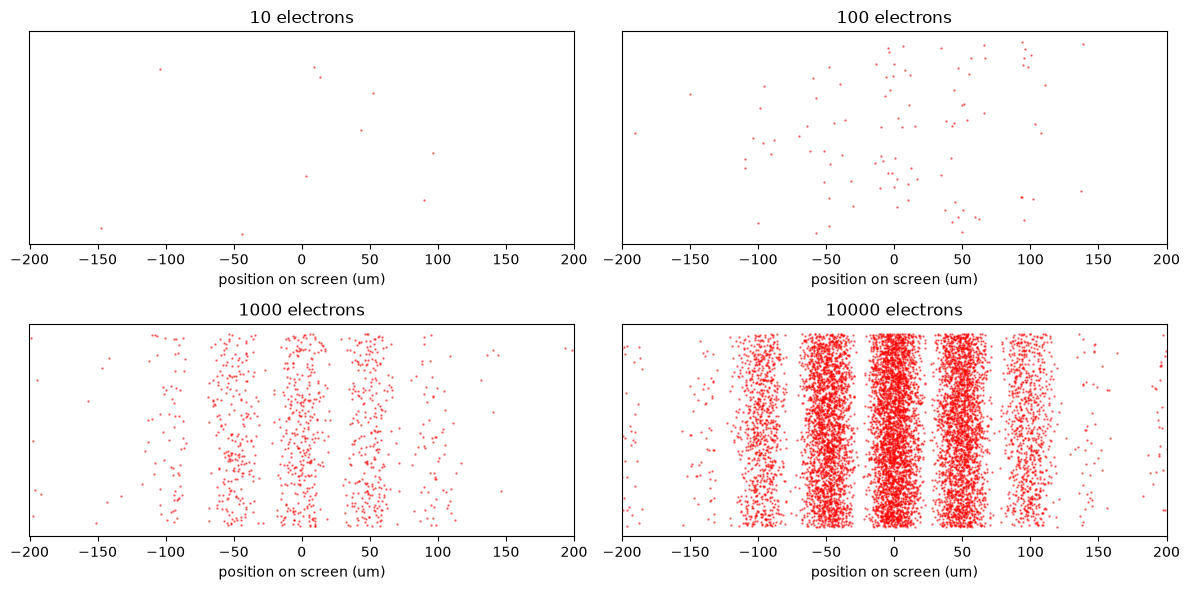

In [1]:
import numpy as np
import matplotlib.pyplot as plt

lambda_, d, a, L = 5e-12, 100e-9, 30e-9, 1.0

xs = np.linspace(-2.5e-4, 2.5e-4, 3000)
theta = xs / L

I = np.sinc(a * theta / lambda_) ** 2 * np.cos(np.pi * d * theta / lambda_) ** 2
p = I / I.sum()

rng = np.random.default_rng(0)

fig, axes = plt.subplots(2, 2, figsize=(12, 6))
for ax, N in zip(axes.ravel(), [10, 100, 1000, 10000]):
    hits = rng.choice(xs, size=N, p=p)
    y = rng.uniform(-1, 1, size=N)
    ax.plot(hits * 1e6, y, ".", ms=1.5, color="red", alpha=0.5)
    ax.set_xlim(-200, 200)
    ax.set_ylim(-1.1, 1.1)
    ax.set_yticks([])
    ax.set_title(f"{N} electrons")
    ax.set_xlabel("position on screen (um)")

plt.tight_layout()
plt.show()

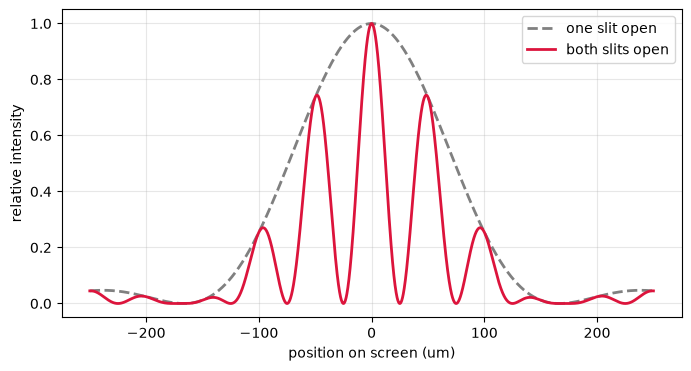

In [2]:
single = np.sinc(a * theta / lambda_) ** 2

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(
    xs * 1e6, single / single.max(), color="gray", lw=2, ls="--", label="one slit open"
)
ax.plot(xs * 1e6, I / I.max(), color="crimson", lw=2, label="both slits open")
ax.set_xlabel("position on screen (um)")
ax.set_ylabel("relative intensity")
ax.legend()
ax.grid(alpha=0.3)
plt.show()